# Trabajo Práctico de Aprendizaje de Máquina

Integrantes:
- Luciana Simón
- Matías Souto
- Yoharlyn Alvarez

# Airline Passenger Satisfaction
Dataset: [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)

Este dataset contiene una encuesta sobre la satisfacción de los pasajeros de una compañía aérea.


| Columna      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `Gender`    | Sexo (`Female`, `Male`)                                                  |
| `Customer Type`         | Tipo de cliente (`Loyal customer`, `disloyal customer`)                                               |
| `Age`         | Edad                                                        |
| `Type of Travel`       | Motivo del viaje (`Personal Travel`, `Business Travel`)                                               |
| `Class`       | Clase de viaje en el avión (`Business`, `Eco`, `Eco Plus`)                                                   |
| `Flight distance`        | Distancia de vuelo                                                        |
| `Inflight wifi service`    | Nivel de satisfacción con el servicio de wifi (`0`:`No Aplica`;`1-5`)          |
| `Departure/Arrival time convenient`       | Nivel de satisfacción con respecto a la conveniencia de los horarios de salida y llegada del vuelo (`0`:`No Aplica`;`1-5`) |
| `Ease of Online booking`         | Nivel de satisfacción con la reserva en línea (`0`:`No Aplica`;`1-5`) |
| `Gate location`  | Nivel de satisfacción con la ubicación de la puerta (`0`:`No Aplica`;`1-5`)                                                    |
| `Food and drink`        | Nivel de satisfacción con la comida y la bebida (`0`:`No Aplica`;`1-5`)                             |
| `Online boarding` | Nivel de satisfacción con los trámites de embarque en línea (`0`:`No Aplica`;`1-5`)                                              |
| `Seat comfort` | Nivel de satisfacción con la comodidad de los asientos (`0`:`No Aplica`;`1-5`)                                               |
| `Inflight entertainment` | Nivel de satisfacción con el entretenimiento a bordo (`0`:`No Aplica`;`1-5`)                                               |
| `On-board service` | Nivel de satisfacción con el servicio para abordar (`0`:`No Aplica`;`1-5`)                                               |
| `Leg room service` | Nivel de satisfacción con el espacio para las piernas (`0`:`No Aplica`;`1-5`)                                               |
| `Baggage handling` | Nivel de satisfacción con la gestión del equipaje (`0`:`No Aplica`;`1-5`)                                               |
| `Check-in service` | Nivel de satisfacción con el servicio de facturación (`0`:`No Aplica`;`1-5`)                                               |
| `Inflight service` | Nivel de satisfacción con el servicio a bordo (`0`:`No Aplica`;`1-5`)                                               |
| `Cleanliness` | Nivel de satisfacción con la limpieza (`0`:`No Aplica`;`1-5`)                                               |
| `Departure Delay in Minutes` | Minutos de retraso en la salida (`0`:`No Aplica`;`1-5`)                                               |
| `Arrival Delay in Minutes`       | Minutos de retraso en la llegada (`0`:`No Aplica`;`1-5`)                                                    |
| `Satisfaction`       | Nivel de satisfacción con la compañía aérea (`satisfied`, `neutral or dissatisfied`)

## Analisis Exploratorio de los datos

In [617]:
import pandas as pd
import zipfile
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import BytesIO
from pandas.api.types import CategoricalDtype
from scipy import stats as st
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif


In [618]:
url = "https://www.kaggle.com/api/v1/datasets/download/teejmahal20/airline-passenger-satisfaction"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.namelist()

['test.csv', 'train.csv']

In [619]:
df_train = pd.read_csv(zip_file.open("train.csv"))
df_test = pd.read_csv(zip_file.open("test.csv"))

In [620]:
df_train_original = df_train.copy()
df_test_original = df_test.copy()

In [621]:
df_train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [622]:
df_train.shape

(103904, 25)

In [623]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [624]:
df_train.iloc[0]

Unnamed: 0                                                 0
id                                                     70172
Gender                                                  Male
Customer Type                                 Loyal Customer
Age                                                       13
Type of Travel                               Personal Travel
Class                                               Eco Plus
Flight Distance                                          460
Inflight wifi service                                      3
Departure/Arrival time convenient                          4
Ease of Online booking                                     3
Gate location                                              1
Food and drink                                             5
Online boarding                                            3
Seat comfort                                               5
Inflight entertainment                                     5
On-board service        

In [625]:
df_train.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [626]:
df_train.duplicated().sum()

np.int64(0)

In [627]:
df_train.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [628]:
df_train.describe(include="object")

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52727,84923,71655,49665,58879


In [629]:
df_train.nunique().sort_values(ascending=False)

Unnamed: 0                           103904
id                                   103904
Flight Distance                        3802
Arrival Delay in Minutes                455
Departure Delay in Minutes              446
Age                                      75
Seat comfort                              6
Cleanliness                               6
Inflight service                          6
Checkin service                           6
Leg room service                          6
On-board service                          6
Inflight entertainment                    6
Food and drink                            6
Online boarding                           6
Gate location                             6
Ease of Online booking                    6
Departure/Arrival time convenient         6
Inflight wifi service                     6
Baggage handling                          5
Class                                     3
Type of Travel                            2
Customer Type                   

### Búsqueda de relación entre variables

In [630]:
numeric_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

nominal_categorical__columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

In [631]:
zero_summary = pd.DataFrame({
    "cantidad_ceros": (df_train[service_columns] == 0).sum(),
    "porcentaje_ceros": (
        (df_train[service_columns] == 0).mean() * 100
    ).round(2)
}).sort_values("porcentaje_ceros", ascending=False)

zero_summary

,cantidad_ceros,porcentaje_ceros
Departure/Arrival time convenient,5300,5.10
Ease of Online booking,4487,4.32
Inflight wifi service,3103,2.99
Online boarding,2428,2.34
Leg room service,472,0.45
Food and drink,107,0.10
Inflight entertainment,14,0.01
Cleanliness,12,0.01
Gate location,1,0.00
Seat comfort,1,0.00


Algunas de las variables que proveen el nivel de satisfacción de los diferentes servicios tienen valores 0. Esto no quiere decir que sea un dato faltante. En la documentación indican que el 0 es equivalente a 'No Aplica'. Por esta razón es que en parte del análisis que hacemos más adelante sobre estas variables, serán descartadas las filas que no apliquen. 

In [632]:
df_plot = df_train.copy()

for col in service_columns:
    df_plot[col] = df_plot[col].replace(0, "No aplica")

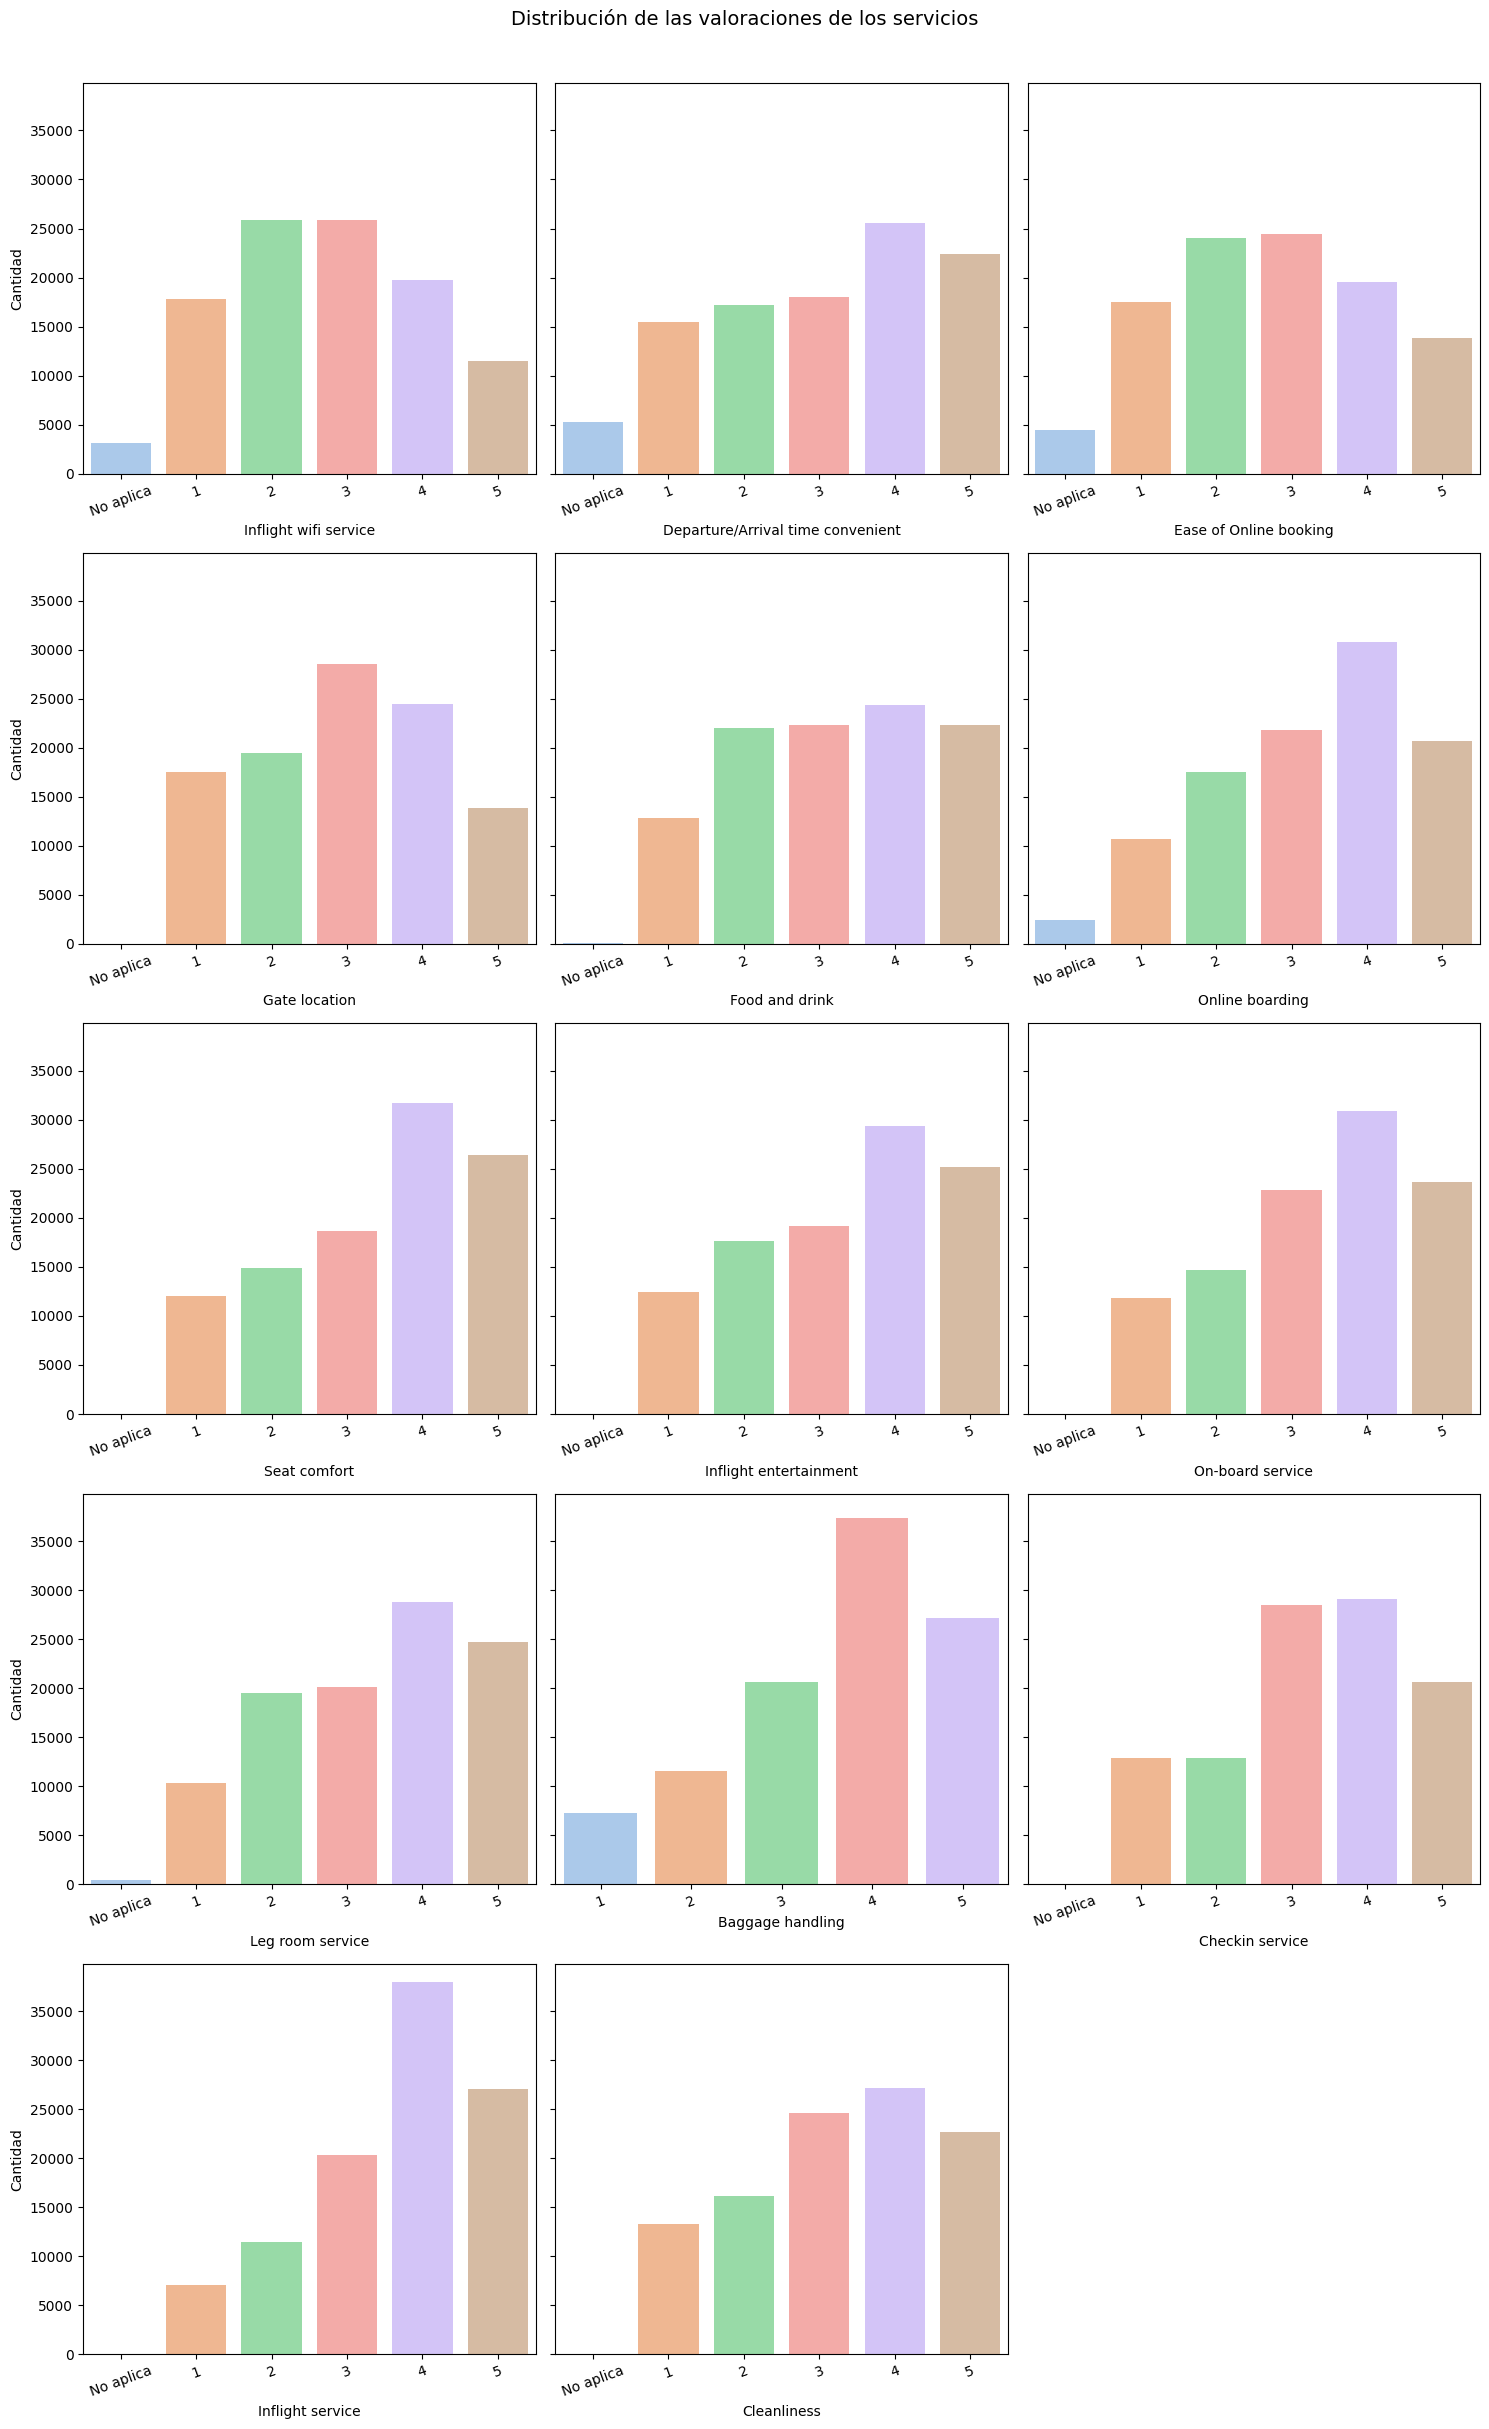

In [633]:
category_order = ["No aplica", 1, 2, 3, 4, 5]

fig, axes = plt.subplots(5, 3, figsize=(15, 24), sharey=True)
axes = axes.flatten()

for i, col in enumerate(service_columns):
    ax = axes[i]

    order = [
        value for value in category_order
        if value in df_plot[col].unique()
    ]

    sns.countplot(
        data=df_plot,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        palette="pastel",
        legend=False,
        ax=ax
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", labelrotation=20)

for ax in axes[len(service_columns):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribución de las valoraciones de los servicios",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

In [634]:
services_for_analysis = df_train[service_columns].replace(0, np.nan)
services_for_analysis.describe()

,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
count,100801.000000,98604.000000,99417.000000,103903.000000,103797.000000,101476.000000,103903.000000,103890.00000,103901.000000,103432.000000,103904.000000,103903.000000,103901.000000,103892.000000
mean,2.813712,3.224788,2.881328,2.976911,3.205430,3.328147,3.439429,3.35861,3.382460,3.366347,3.631833,3.304322,3.640533,3.286730
std,1.257367,1.385790,1.298773,1.277594,1.326235,1.267246,1.319051,1.33251,1.288245,1.298936,1.180903,1.265360,1.175517,1.311873
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.00000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


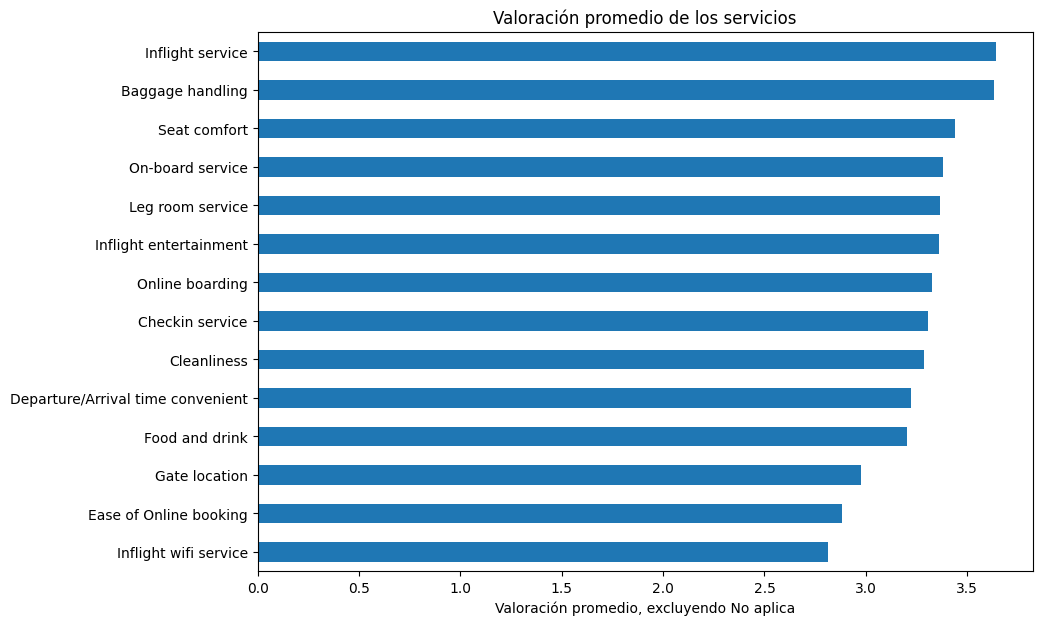

In [635]:
mean_services = (
    services_for_analysis
    .mean()
    .sort_values()
)

mean_services.plot(kind="barh", figsize=(10, 7))
plt.xlabel("Valoración promedio, excluyendo No aplica")
plt.title("Valoración promedio de los servicios")
plt.show()

In [636]:
df_analysis = df_train.copy()

df_analysis[numeric_columns] = (
    df_analysis[numeric_columns]
    .astype("float64")
)

df_analysis[nominal_categorical__columns] = (
    df_analysis[nominal_categorical__columns]
    .astype("category")
)

service_dtype = CategoricalDtype(
    categories=[1, 2, 3, 4, 5],
    ordered=True
)

for col in service_columns:
    df_analysis[col] = (
        df_analysis[col]
        .replace(0, np.nan)
        .astype(service_dtype)
    )

df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Unnamed: 0                         103904 non-null  int64   
 1   id                                 103904 non-null  int64   
 2   Gender                             103904 non-null  category
 3   Customer Type                      103904 non-null  category
 4   Age                                103904 non-null  float64 
 5   Type of Travel                     103904 non-null  category
 6   Class                              103904 non-null  category
 7   Flight Distance                    103904 non-null  float64 
 8   Inflight wifi service              100801 non-null  category
 9   Departure/Arrival time convenient  98604 non-null   category
 10  Ease of Online booking             99417 non-null   category
 11  Gate location             

In [637]:
df_analysis["Inflight wifi service"].dtype

CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True, categories_dtype=int64)

In [638]:
def get_frecuency(dataframe, columna):
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [639]:
get_frecuency(df_analysis, 'Customer Type')

Frecuencias de cada categoría en la variable 'Customer Type':
                   Frecuencia absoluta  Frecuencia relativa (%)
Customer Type                                                  
Loyal Customer                   84923                    81.73
disloyal Customer                18981                    18.27



In [640]:
get_frecuency(df_analysis, 'Class')

Frecuencias de cada categoría en la variable 'Class':
          Frecuencia absoluta  Frecuencia relativa (%)
Class                                                 
Business                49665                    47.80
Eco                     46745                    44.99
Eco Plus                 7494                     7.21



In [641]:
get_frecuency(df_analysis, 'satisfaction')

Frecuencias de cada categoría en la variable 'satisfaction':
                         Frecuencia absoluta  Frecuencia relativa (%)
satisfaction                                                         
neutral or dissatisfied                58879                    56.67
satisfied                              45025                    43.33



In [642]:
pearson_corr = df_analysis[numeric_columns].corr(method="pearson")
pearson_corr

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.099461,-0.010152,-0.012147
Flight Distance,0.099461,1.000000,0.002158,-0.002426
Departure Delay in Minutes,-0.010152,0.002158,1.000000,0.965481
Arrival Delay in Minutes,-0.012147,-0.002426,0.965481,1.000000


In [643]:
spearman_continuous = df_analysis[numeric_columns].corr(method="spearman")
spearman_continuous

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.072321,-0.010894,-0.012439
Flight Distance,0.072321,1.000000,0.026570,-0.001468
Departure Delay in Minutes,-0.010894,0.026570,1.000000,0.740843
Arrival Delay in Minutes,-0.012439,-0.001468,0.740843,1.000000


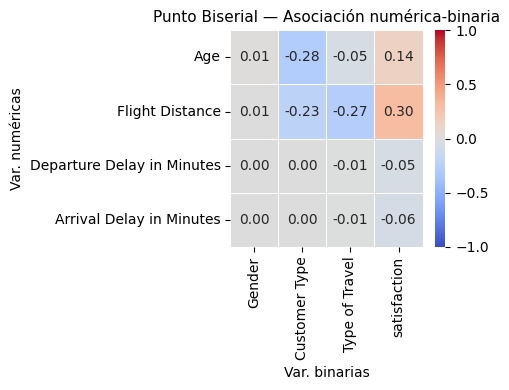

In [644]:
binary_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "satisfaction"
]

pb_values = np.empty(
    (len(numeric_columns), len(binary_columns)),
    dtype=float
)

for i, num_col in enumerate(numeric_columns):
    for j, bin_col in enumerate(binary_columns):
        mask = (
            df_analysis[num_col].notna()
            & df_analysis[bin_col].notna()
        )

        num = (
            df_analysis.loc[mask, num_col]
            .to_numpy(dtype=float)
        )

        bn = (
            df_analysis.loc[mask, bin_col]
            .cat.codes
            .to_numpy(dtype=float)
        )

        pb_values[i, j] = np.corrcoef(bn, num)[0, 1]


pb_mat = pd.DataFrame(
    pb_values,
    index=numeric_columns,
    columns=binary_columns
)
        

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5,
            center=0, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

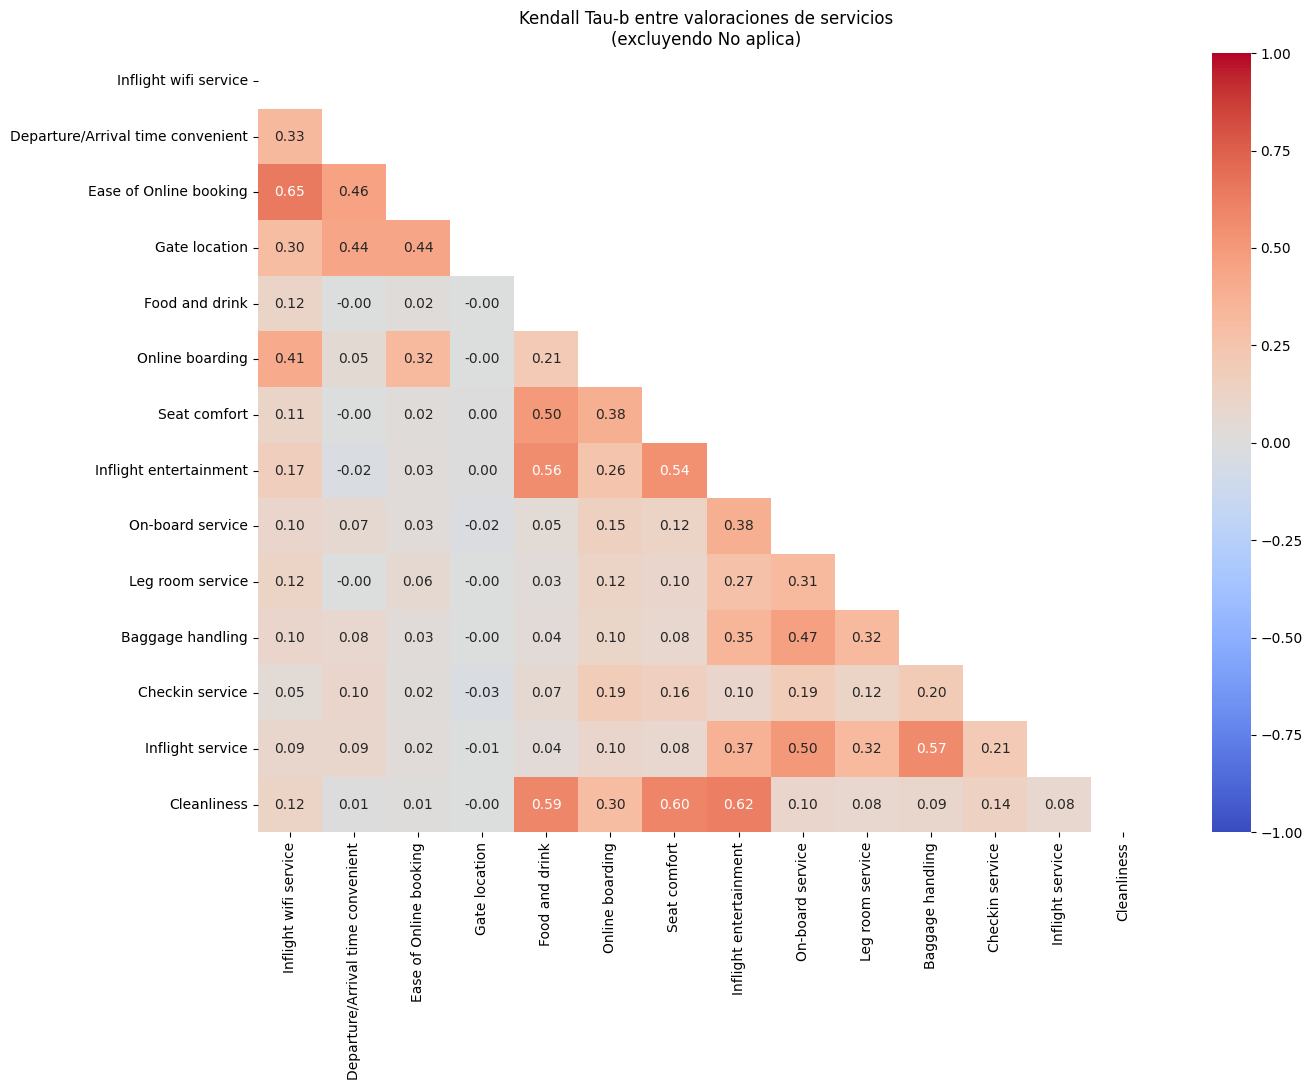

In [645]:
services_for_corr = (
    df_train[service_columns]
    .replace(0, np.nan)
)

corr_kendall = services_for_corr.corr(method="kendall")

plt.figure(figsize=(14, 11))

mask = np.triu(
    np.ones_like(corr_kendall, dtype=bool)
)

sns.heatmap(
    corr_kendall,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Kendall Tau-b entre valoraciones de servicios\n"
    "(excluyendo No aplica)"
)
plt.tight_layout()
plt.show()

In [646]:
binary_column = "satisfaction"

results_tau = {}

for ord_col in service_columns:
    mask = (
        df_analysis[binary_column].notna()
        & df_analysis[ord_col].notna()
    )

    binary_codes = (
        df_analysis.loc[mask, binary_column]
        .cat.codes
    )

    ordinal_codes = (
        df_analysis.loc[mask, ord_col]
        .cat.codes
    )

    tau, p_value = kendalltau(
        binary_codes,
        ordinal_codes,
        variant="b"
    )

    results_tau[ord_col] = {
        "tau_b": tau,
        "p_value": p_value,
        "n": mask.sum()
    }

kendall_results = pd.DataFrame(results_tau).T

In [647]:
kendall_results = kendall_results.loc[
    kendall_results["tau_b"]
    .abs()
    .sort_values()
    .index
]

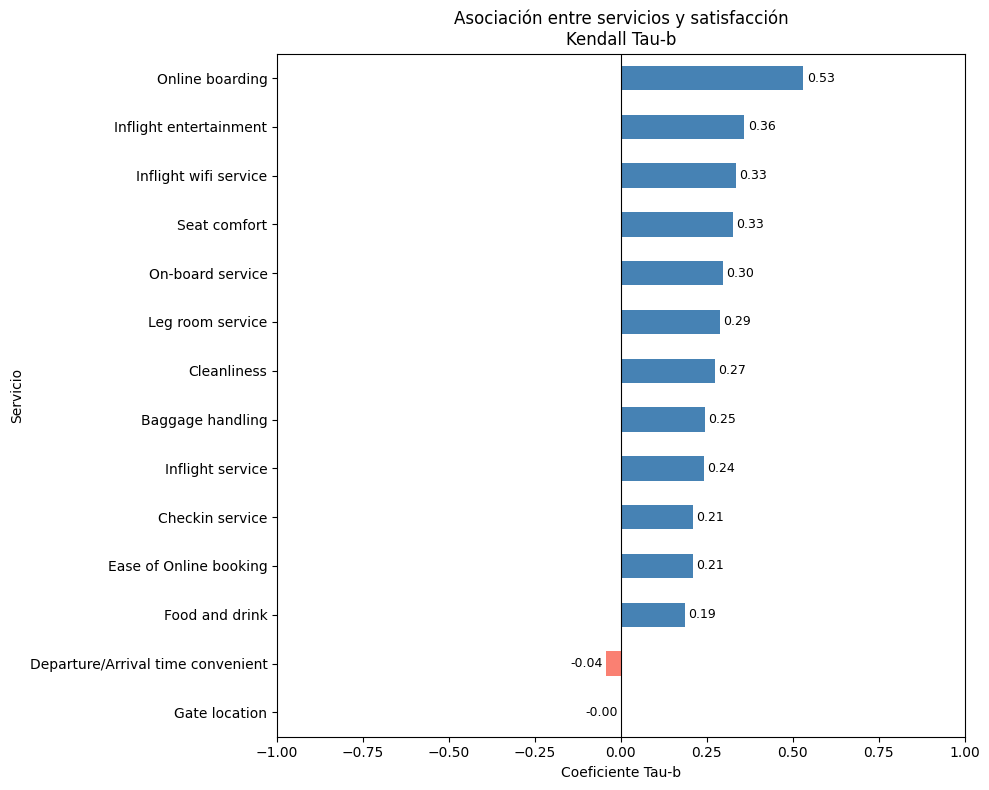

In [648]:
plt.figure(figsize=(10, 8))

tau_values = kendall_results["tau_b"].to_numpy(dtype=float)

colors = [
    "salmon" if value < 0 else "steelblue"
    for value in tau_values
]

ax = kendall_results["tau_b"].plot(
    kind="barh",
    color=colors
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xlim(-1, 1)

ax.set_title(
    "Asociación entre servicios y satisfacción\n"
    "Kendall Tau-b"
)

ax.set_xlabel("Coeficiente Tau-b")
ax.set_ylabel("Servicio")

for y_position, value in enumerate(tau_values):
    ax.text(
        x=value + 0.01 if value >= 0 else value - 0.01,
        y=y_position,
        s=f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

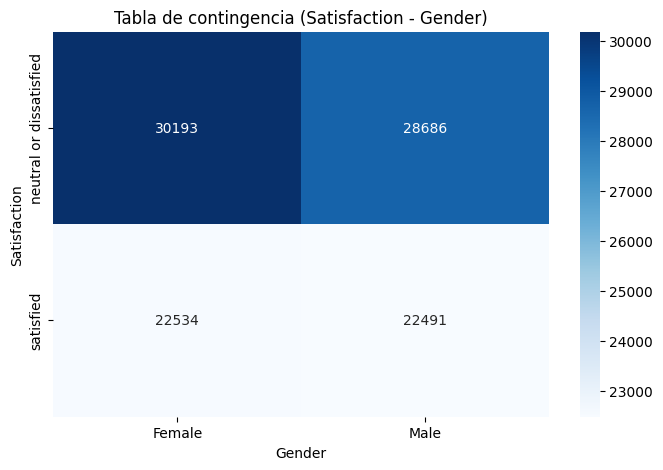

In [649]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_analysis['satisfaction'], df_analysis['Gender'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Gender)')
plt.xlabel('Gender')
plt.ylabel('Satisfaction')
plt.show()

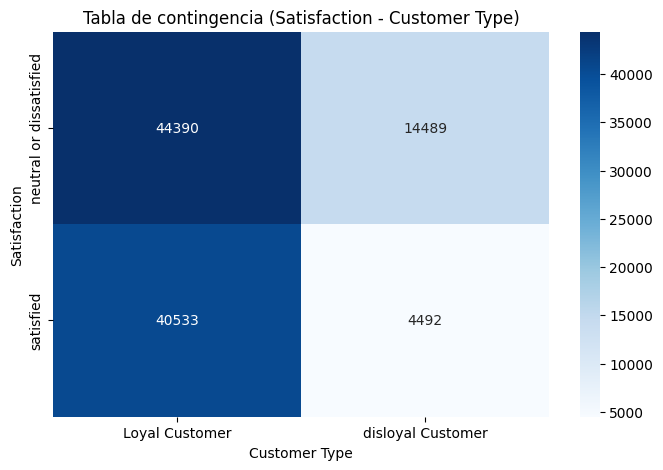

In [650]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_analysis['satisfaction'], df_analysis['Customer Type'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Customer Type)')
plt.xlabel('Customer Type')
plt.ylabel('Satisfaction')
plt.show()

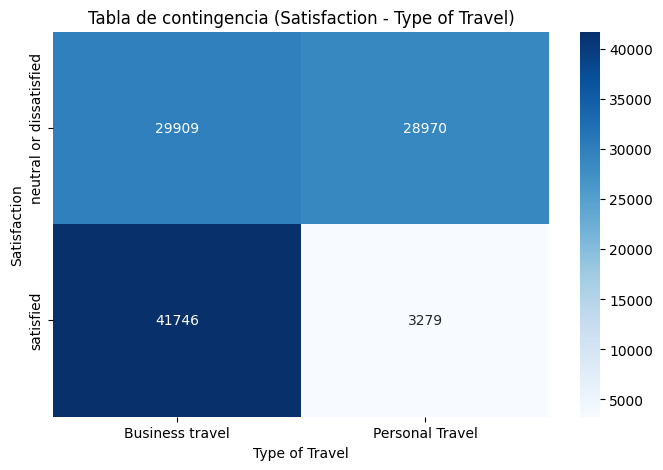

In [651]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_analysis['satisfaction'], df_analysis['Type of Travel'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Type of Travel)')
plt.xlabel('Type of Travel')
plt.ylabel('Satisfaction')
plt.show()

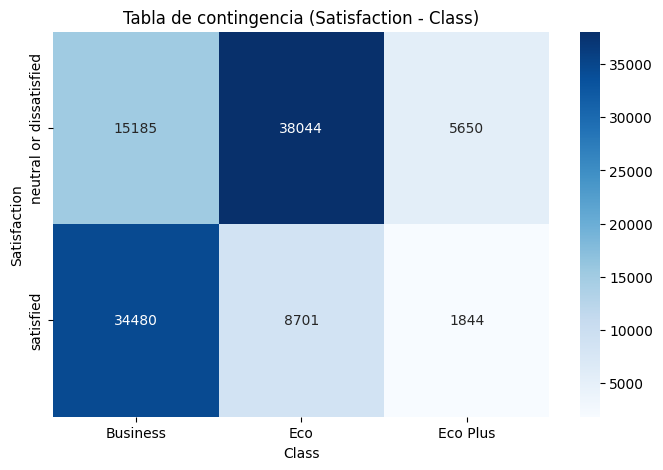

In [652]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_analysis['satisfaction'], df_analysis['Class'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Class)')
plt.xlabel('Class')
plt.ylabel('Satisfaction')
plt.show()

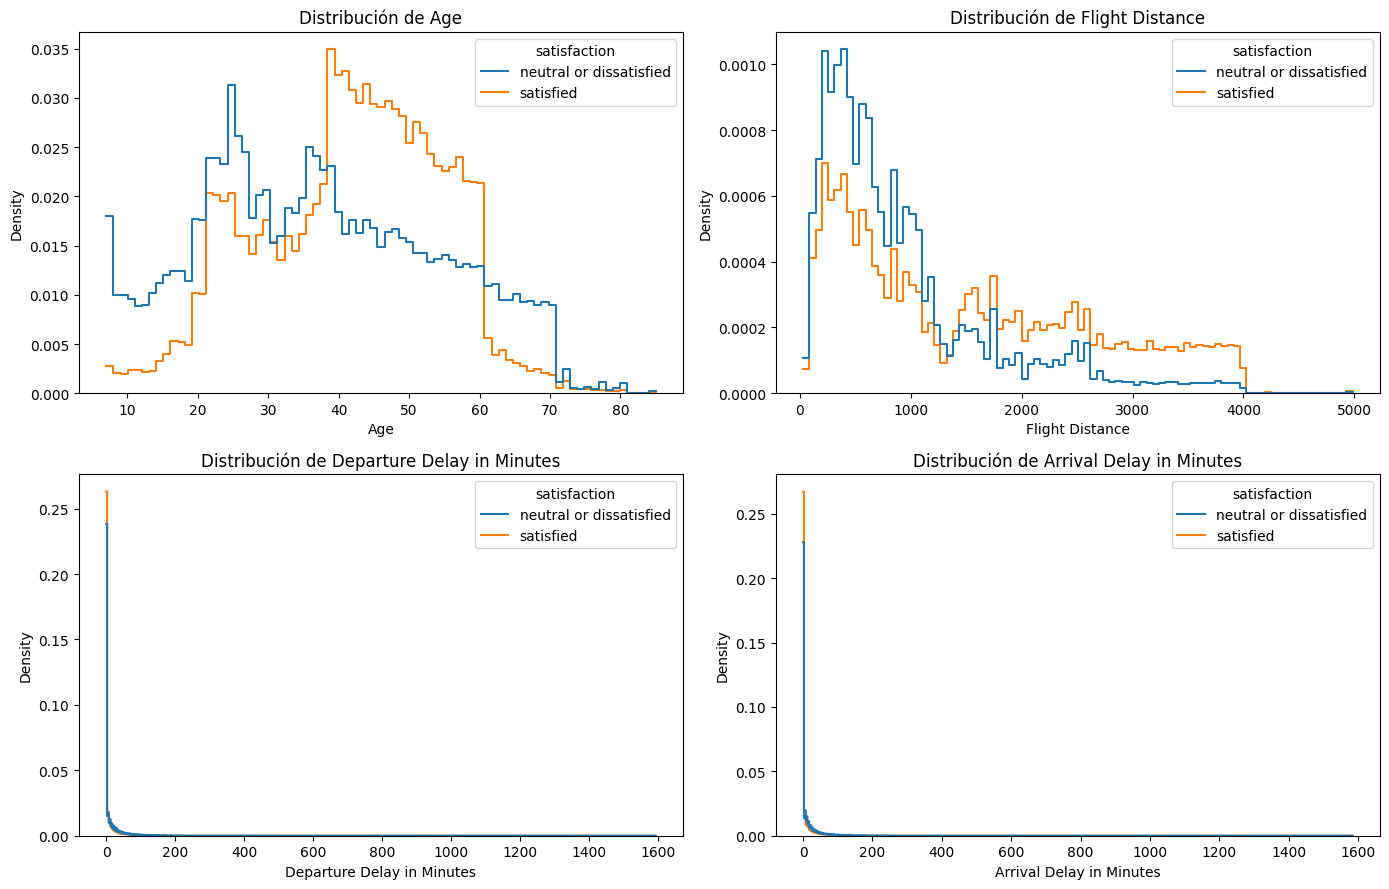

In [653]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.histplot(
        data=df_analysis,
        x=col,
        hue="satisfaction",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

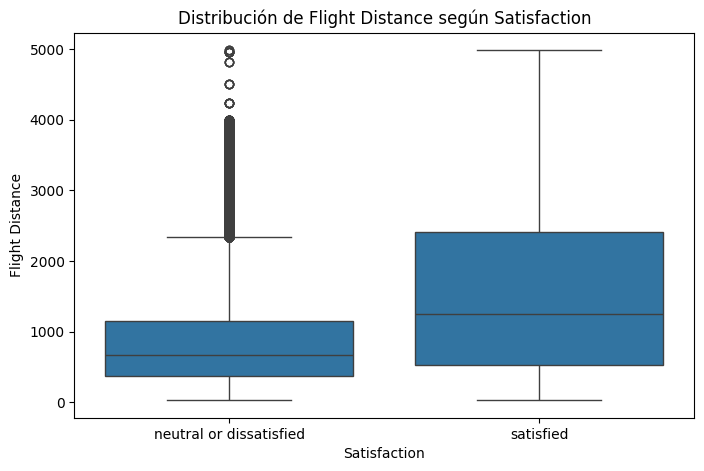

In [654]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_analysis,
    x="satisfaction",
    y="Flight Distance"

)

plt.title("Distribución de Flight Distance según Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")
plt.show()

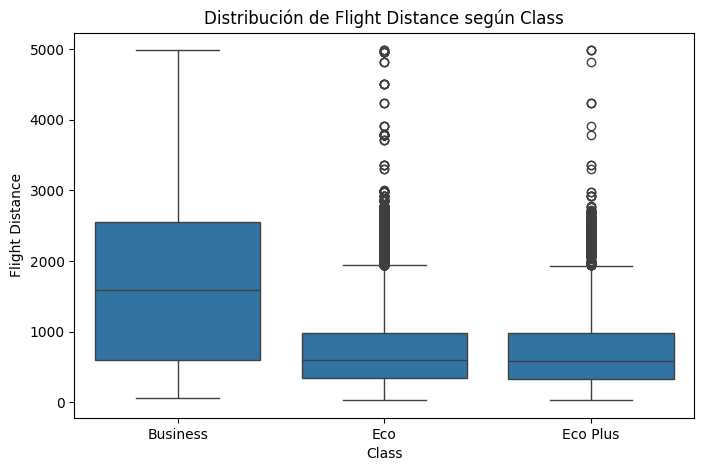

In [655]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_analysis,
    x="Class",
    y="Flight Distance"

)

plt.title("Distribución de Flight Distance según Class")
plt.xlabel("Class")
plt.ylabel("Flight Distance")
plt.show()

In [656]:
Q1 = df_analysis['Flight Distance'].quantile(0.25)
Q3 = df_analysis['Flight Distance'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

outliers = df_analysis[
    (df_analysis['Flight Distance'] < lower_bound) |
    (df_analysis['Flight Distance'] > upper_bound)
]

print(f"Cantidad de outliers: {len(outliers)}")

Q1: 414.0
Q3: 1743.0
IQR: 1329.0
Límite inferior: -1579.5
Límite superior: 3736.5
Cantidad de outliers: 2291


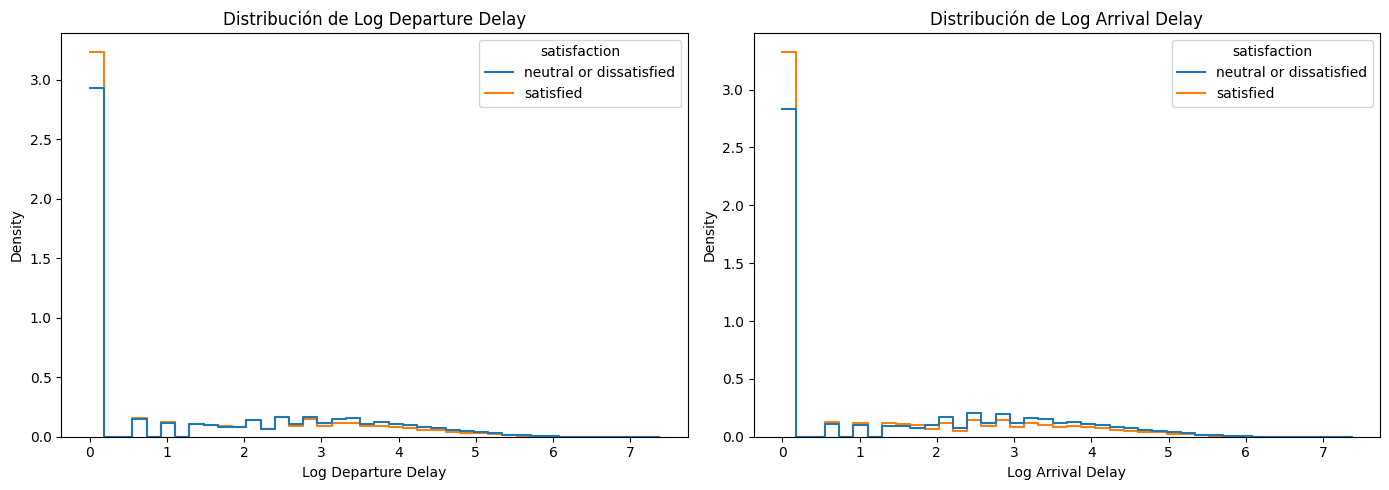

In [657]:
df_plot = df_analysis.copy()

df_plot["Log Departure Delay"] = np.log1p(
    df_plot["Departure Delay in Minutes"]
)

df_plot["Log Arrival Delay"] = np.log1p(
    df_plot["Arrival Delay in Minutes"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(
    axes,
    ["Log Departure Delay", "Log Arrival Delay"]
):
    sns.histplot(
        data=df_plot,
        x=col,
        hue="satisfaction",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=40,
        ax=ax
    )

    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**Resumen de hallazgos:** La variable de satisfacción presenta un desbalance moderado: el 56,67 % de los pasajeros lo calificó neutral o insatisfecho y el 43,33 % satisfecho. La satisfacción se relaciona especialmente con el tipo de viaje, la clase y la fidelidad del cliente: es mayor entre clientes leales, con motivo de viaje de negocios y que viajan en clase Business. Por otra parte, vemos que el género no es relavante en esta calificación.

Entre los servicios, Online boarding presenta la asociación ordinal más fuerte con la satisfacción (Kendall Tau-b = 0,53), seguido por Inflight entertainment (0,36), Inflight wifi service y Seat comfort (0,33). En cambio, Gate location y Departure/Arrival time convenient muestran asociaciones prácticamente nulas. Respecto de las variables numéricas continuas, las demoras de salida y llegada están fuertemente correlacionadas (Pearson = 0,97), mientras que las restantes relaciones son débiles. También se observa que los pasajeros satisfechos tienden a realizar vuelos más largos y a presentar menores demoras.

### Datos faltantes

In [658]:
missing_summary = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": (
        df_train.isna().mean() * 100
    ).round(4)
})

missing_summary

,cantidad_faltantes,porcentaje_faltantes
Unnamed: 0,0,0.0000
id,0,0.0000
Gender,0,0.0000
Customer Type,0,0.0000
Age,0,0.0000
Type of Travel,0,0.0000
Class,0,0.0000
Flight Distance,0,0.0000
Inflight wifi service,0,0.0000
Departure/Arrival time convenient,0,0.0000


La única columna que posee valores nulos es **Arrival Delay in Minutes** con un porcentaje bajo: **0.2984%**.

A continuación tratamos de identificar un patrón para la ausencia de este valor. De esa forma podemos establecer el mecanismo más adecuado para tratar esos datos faltantes.

In [659]:
def get_null_groups(df, group_col, target_col):
    result = (
        df.groupby(group_col, observed=True)[target_col]
        .agg(
            cantidad_total="size",
            cantidad_nulos=lambda x: x.isna().sum()
        )
        .reset_index()
    )

    result["porcentaje_nulos"] = (
        result["cantidad_nulos"]
        / result["cantidad_total"]
        * 100
    )

    return result.sort_values(
        "porcentaje_nulos",
        ascending=False
    )

In [660]:
group_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

for col in group_columns:
    display(
        get_null_groups(
            df_train,
            col,
            "Arrival Delay in Minutes"
        )
    )

,Gender,cantidad_total,cantidad_nulos,porcentaje_nulos
1,Male,51177,159,0.310686
0,Female,52727,151,0.286381


,Customer Type,cantidad_total,cantidad_nulos,porcentaje_nulos
0,Loyal Customer,84923,261,0.307337
1,disloyal Customer,18981,49,0.258153


,Type of Travel,cantidad_total,cantidad_nulos,porcentaje_nulos
1,Personal Travel,32249,120,0.372105
0,Business travel,71655,190,0.265159


,Class,cantidad_total,cantidad_nulos,porcentaje_nulos
2,Eco Plus,7494,26,0.346944
1,Eco,46745,152,0.325168
0,Business,49665,132,0.265781


,satisfaction,cantidad_total,cantidad_nulos,porcentaje_nulos
0,neutral or dissatisfied,58879,182,0.309109
1,satisfied,45025,128,0.284287


In [661]:
df_missing = df_train.copy()

df_missing["arrival_delay_missing"] = (
    df_missing["Arrival Delay in Minutes"].isna()
)

numeric_missing_comparison = (
    df_missing
    .groupby("arrival_delay_missing")[
        [
            "Age",
            "Flight Distance",
            "Departure Delay in Minutes"
        ]
    ]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

numeric_missing_comparison

Age                      Flight Distance           \
                        count   mean median    std           count     mean   
arrival_delay_missing                                                         
False                  103594  39.38   40.0  15.11          103594  1189.33   
True                      310  39.13   39.0  15.74             310  1230.61   

                                     Departure Delay in Minutes                \
                      median     std                      count   mean median   
arrival_delay_missing                                                           
False                  842.0  997.30                     103594  14.75    0.0   
True                   945.0  946.33                        310  37.43    8.0   

                              
                         std  
arrival_delay_missing         
False                  38.12  
True                   62.24

In [662]:
df_missing["departure_delay_group"] = pd.cut(
    df_missing["Departure Delay in Minutes"],
    bins=[-1, 0, 15, 60, np.inf],
    labels=[
        "Sin demora",
        "1–15 minutos",
        "16–60 minutos",
        "Más de 60 minutos"
    ]
)

missing_by_departure_delay = (
    df_missing
    .groupby("departure_delay_group", observed=True)
    .agg(
        cantidad_total=(
            "arrival_delay_missing",
            "size"
        ),
        cantidad_nulos=(
            "arrival_delay_missing",
            "sum"
        ),
        porcentaje_nulos=(
            "arrival_delay_missing",
            "mean"
        )
    )
)

missing_by_departure_delay["porcentaje_nulos"] *= 100

missing_by_departure_delay.round(3)

,cantidad_total,cantidad_nulos,porcentaje_nulos
departure_delay_group,,,
Sin demora,58668,116,0.198
1–15 minutos,22184,58,0.261
16–60 minutos,15813,68,0.430
Más de 60 minutos,7239,68,0.939


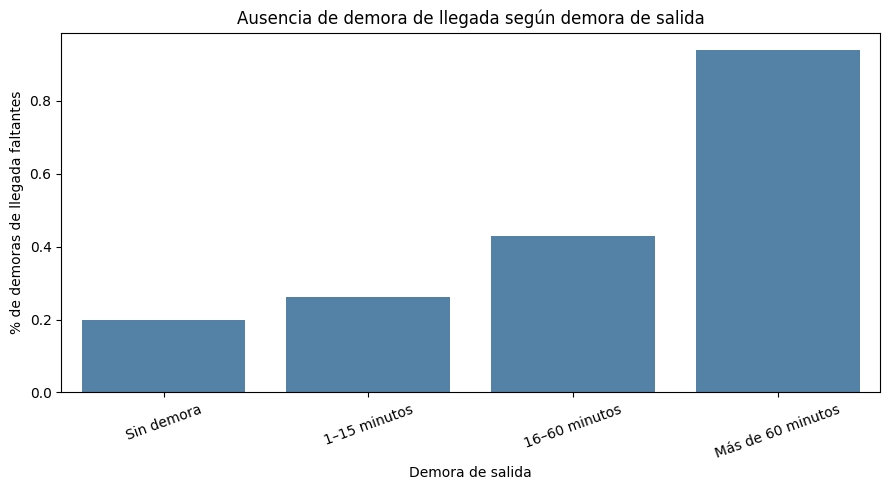

In [663]:
plot_data = missing_by_departure_delay.reset_index()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_data,
    x="departure_delay_group",
    y="porcentaje_nulos",
    color="steelblue"
)

plt.xlabel("Demora de salida")
plt.ylabel("% de demoras de llegada faltantes")
plt.title(
    "Ausencia de demora de llegada según demora de salida"
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Observamos que la tasa de valores faltantes en **Arrival Delay in Minutes** aumenta progresivamente con **Departure Delay in Minutes**.

Este patrón observado sugiere que la ausencia no es completamente aleatoria y es compatible con una causa de tipo **MAR** relacionado con la demora de salida.

## Planteamiento del problema
El problema que planteamos es de tipo clasificación binaria (`satisfied`, `neutral or dissatisfied`).

Queremos predecir si un cliente calificará el vuelo como satisfactorio o no. 

In [664]:
summary_by_satisfaction = (
    df_analysis
    .groupby("satisfaction")[numeric_columns]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

summary_by_satisfaction

/var/folders/bp/wgmvnypn6ts_jxrwb_4qn2qr0000gn/T/ipykernel_14339/1441138269.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("satisfaction")[numeric_columns]


Age                      Flight Distance           \
                         count   mean median    std           count     mean   
satisfaction                                                                   
neutral or dissatisfied  58879  37.57   36.0  16.46           58879   928.92   
satisfied                45025  41.75   43.0  12.77           45025  1530.14   

                                         Departure Delay in Minutes         \
                         median      std                      count   mean   
satisfaction                                                                 
neutral or dissatisfied   671.0   790.45                      58879  16.50   
satisfied                1250.0  1128.13                      45025  12.61   

                                      Arrival Delay in Minutes                \
                        median    std                    count   mean median   
satisfaction                                                                   
neutral or dissatisfied    0.0  40.19                    58697  17.13    0.0   
satisfied                  0.0  35.38                    44897  12.63    0.0   

                                
                           std  
satisfaction                    
neutral or dissatisfied  40.56  
satisfied                35.96

## Limpieza y Transformaciones

### Tratamiento de faltantes
Para cada valor faltante, utilizaremos la mediana de Arrival Delay in Minutes correspondiente a su grupo según la columna Departure Delay in Minutes.

In [665]:
departure_bins = [-1, 0, 15, 60, np.inf]

departure_labels = [
    "Sin demora",
    "1–15 minutos",
    "16–60 minutos",
    "Más de 60 minutos"
]

df_train["departure_delay_group"] = pd.cut(
    df_train["Departure Delay in Minutes"],
    bins=departure_bins,
    labels=departure_labels
)

arrival_medians_by_group = (
    df_train
    .groupby(
        "departure_delay_group",
        observed=True
    )["Arrival Delay in Minutes"]
    .median()
)

arrival_medians_by_group

departure_delay_group
Sin demora            0.0
1–15 minutos          2.0
16–60 minutos        26.0
Más de 60 minutos    99.0
Name: Arrival Delay in Minutes, dtype: float64

In [666]:
conditional_medians = (
    df_train["departure_delay_group"]
    .astype("object")
    .map(arrival_medians_by_group)
)

df_train["Arrival Delay in Minutes"] = (
    df_train["Arrival Delay in Minutes"]
    .fillna(conditional_medians)
    .astype("float64")
)

df_train.drop(
    columns="departure_delay_group",
    inplace=True
)

In [667]:
df_train.isna().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [668]:
df_test["departure_delay_group"] = pd.cut(
    df_test["Departure Delay in Minutes"],
    bins=departure_bins,
    labels=departure_labels
)

test_conditional_medians = (
    df_test["departure_delay_group"]
    .astype("object")
    .map(arrival_medians_by_group)
)

df_test["Arrival Delay in Minutes"] = (
    df_test["Arrival Delay in Minutes"]
    .fillna(test_conditional_medians)
    .astype("float64")
)

df_test.drop(
    columns="departure_delay_group",
    inplace=True
)

### Codificación
Aplicamos codificación a las variables categóricas nominales utilizando **One-Hot Encoding**

In [669]:
nominal_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    dtype=np.float64
)

train_encoded_array = ohe.fit_transform(df_train[nominal_columns])

test_encoded_array = ohe.transform(df_test[nominal_columns])

encoded_columns = ohe.get_feature_names_out(nominal_columns)

train_encoded_df = pd.DataFrame(
    data=np.asarray(
        train_encoded_array,
        dtype=np.float64
    ),
    columns=encoded_columns.tolist(),
    index=df_train.index.copy()
)

test_encoded_df = pd.DataFrame(
    data=np.asarray(
        test_encoded_array,
        dtype=np.float64
    ),
    columns=encoded_columns.tolist(),
    index=df_test.index.copy()
)

df_train = (
    df_train
    .drop(columns=nominal_columns)
    .join(train_encoded_df)
)

df_test = (
    df_test
    .drop(columns=nominal_columns)
    .join(test_encoded_df)
)

Aplicamos **Label Encoding** para codificar la variable target (Satisfaction)

In [670]:
label_encoder = LabelEncoder()

train_target_encoded = label_encoder.fit_transform(
    df_train["satisfaction"]
)

test_target_encoded = label_encoder.transform(
    df_test["satisfaction"]
)

df_train["satisfaction"] = pd.Series(
    data=np.asarray(
        train_target_encoded,
        dtype=np.int64
    ),
    index=df_train.index,
    dtype="int64"
)

df_test["satisfaction"] = pd.Series(
    data=np.asarray(
        test_target_encoded,
        dtype=np.int64
    ),
    index=df_test.index,
    dtype="int64"
)

In [671]:
df_train.head()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,satisfaction,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,70172,13,460,3,4,3,1,5,3,...,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1,5047,25,235,3,2,3,3,1,3,...,0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,2,110028,26,1142,2,2,2,2,5,5,...,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,3,24026,25,562,2,5,5,5,2,2,...,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,4,119299,61,214,3,3,3,3,4,5,...,1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [672]:
df_test.head()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,...,satisfaction,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,19556,52,160,5,4,3,4,3,4,...,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,90035,36,2863,1,1,3,1,5,4,...,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2,12360,20,192,2,0,2,4,2,2,...,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,3,77959,44,3377,0,0,0,2,3,4,...,1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,4,36875,49,1182,2,3,4,3,4,1,...,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [673]:
df_train["satisfaction"].value_counts()

satisfaction
0    58879
1    45025
Name: count, dtype: int64

### Selección de features

In [674]:
TARGET = "satisfaction"

num_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

cat_ord_features = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

cat_nom_features = (
    ohe
    .get_feature_names_out(
        nominal_columns
    )
    .tolist()
)

cat_features = (
    cat_nom_features
    + cat_ord_features
)

all_features = (
    num_features
    + cat_features
)

In [675]:
X_train_num = (
    df_train[num_features]
    .astype(float)
)

X_train_cat = (
    df_train[cat_features]
    .astype(float)
)

y_train = (
    df_train[TARGET]
    .astype(int)
)

In [676]:
selector_anova = SelectKBest(score_func=f_classif, k="all")
selector_anova.fit(X_train_num, y_train)

if selector_anova.scores_ is None:
    raise RuntimeError(
        "SelectKBest no generó los scores de ANOVA"
    )

if selector_anova.pvalues_ is None:
    raise RuntimeError(
        "SelectKBest no generó los p-values de ANOVA"
    )

anova_scores_array = np.asarray(
    selector_anova.scores_,
    dtype=np.float64
)

anova_pvalues_array = np.asarray(
    selector_anova.pvalues_,
    dtype=np.float64
)

anova_scores = pd.Series(
    {
        feature: float(score)
        for feature, score in zip(
            num_features,
            anova_scores_array
        )
    },
    name="ANOVA_F"
)

anova_pvalues = pd.Series(
    {
        feature: float(p_value)
        for feature, p_value in zip(
            num_features,
            anova_pvalues_array
        )
    },
    name="ANOVA_p_value"
)

In [677]:
anova_results = (
    pd.DataFrame({
        "score": anova_scores,
        "p_value": anova_pvalues
    })
    .sort_values(
        "score",
        ascending=False
    )
)

display(
    anova_results.style.format({
        "score": "{:.2f}",
        "p_value": "{:.6f}"
    })
)

,score,p_value
Flight Distance,10184.42,0.000000
Age,1992.39,0.000000
Arrival Delay in Minutes,344.44,0.000000
Departure Delay in Minutes,265.59,0.000000


In [678]:
selector_chi2 = SelectKBest(score_func=chi2, k="all")
selector_chi2.fit(X_train_cat, y_train)

if selector_chi2.scores_ is None:
    raise RuntimeError(
        "SelectKBest no generó los scores de Chi²"
    )

if selector_chi2.pvalues_ is None:
    raise RuntimeError(
        "SelectKBest no generó los p-values de Chi²"
    )

chi2_scores_array = np.asarray(
    selector_chi2.scores_,
    dtype=np.float64
)

chi2_pvalues_array = np.asarray(
    selector_chi2.pvalues_,
    dtype=np.float64
)

chi2_scores = pd.Series(
    {
        feature: float(score)
        for feature, score in zip(
            cat_features,
            chi2_scores_array
        )
    },
    name="chi2"
)

chi2_pvalues = pd.Series(
    {
        feature: float(p_value)
        for feature, p_value in zip(
            cat_features,
            chi2_pvalues_array
        )
    },
    name="chi2_p_value"
)

In [679]:
chi2_results = (
    pd.DataFrame({
        "score": chi2_scores,
        "p_value": chi2_pvalues
    })
    .sort_values(
        "score",
        ascending=False
    )
)

display(
    chi2_results.style.format({
        "score": "{:.2f}",
        "p_value": "{:.6f}"
    })
)

,score,p_value
Online boarding,14761.96,0.000000
Type of Travel_Personal Travel,14445.75,0.000000
Class_Business,13769.29,0.000000
Class_Eco,11632.29,0.000000
Inflight entertainment,8711.18,0.000000
Type of Travel_Business travel,6501.44,0.000000
Seat comfort,6419.26,0.000000
Inflight wifi service,5422.33,0.000000
On-board service,5299.34,0.000000
Leg room service,5261.98,0.000000


In [680]:
mi_num = mutual_info_classif(X_train_num, y_train, discrete_features=False, random_state=42)
mi_num_series = pd.Series(mi_num, index=num_features, name="MI")

mi_cat = mutual_info_classif(X_train_cat, y_train, discrete_features=True, random_state=42)
mi_cat_series = pd.Series(mi_cat, index=cat_features, name="MI")

mi_all = pd.concat([mi_num_series, mi_cat_series])

mi_results = (
    mi_all
    .sort_values(
        ascending=False
    )
    .to_frame()
)

mi_results

,MI
Online boarding,0.210858
Inflight wifi service,0.161702
Class_Business,0.132830
Type of Travel_Business travel,0.113635
Type of Travel_Personal Travel,0.113635
Class_Eco,0.107171
Inflight entertainment,0.093717
Seat comfort,0.078879
Leg room service,0.060730
Flight Distance,0.060487


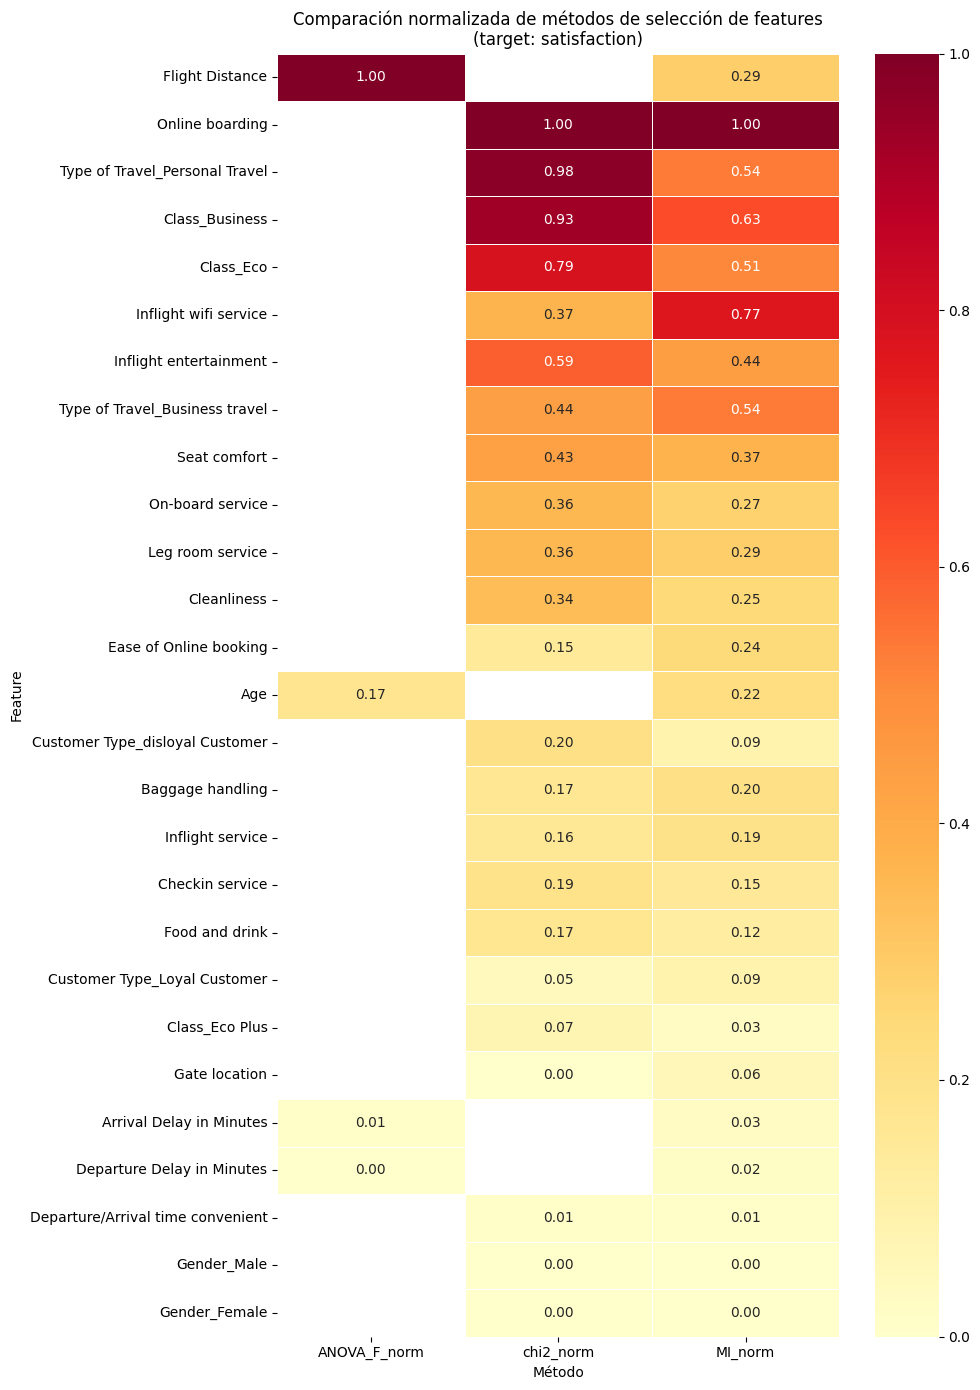

In [681]:
comparison_df = pd.DataFrame(index=all_features)

comparison_df["ANOVA_F_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        anova_scores
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=num_features
)

comparison_df["chi2_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        chi2_scores
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=cat_features
)

comparison_df["MI_norm"] = pd.Series(
    MinMaxScaler()
    .fit_transform(
        mi_all
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten(),
    index=all_features
)

comparison_df["max_score"] = (
    comparison_df[
        [
            "ANOVA_F_norm",
            "chi2_norm",
            "MI_norm"
        ]
    ]
    .max(axis=1)
)

comparison_df = (
    comparison_df
    .sort_values(
        "max_score",
        ascending=False
    )
    .drop(columns="max_score")
)

plt.figure(figsize=(10, 14))

sns.heatmap(
    comparison_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Comparación normalizada de métodos "
    "de selección de features\n"
    "(target: satisfaction)"
)

plt.xlabel("Método")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [684]:
selected_features = [
    # Numéricas
    "Age",
    "Flight Distance",
    "Arrival Delay in Minutes",

    # Variables nominales codificadas
    "Type of Travel_Personal Travel",
    "Class_Business",
    "Class_Eco",
    "Customer Type_disloyal Customer",

    # Servicios (ordinales)
    "Online boarding",
    "Inflight wifi service",
    "Inflight entertainment",
    "Seat comfort",
    "On-board service",
    "Leg room service",
    "Cleanliness",
    "Ease of Online booking",
    "Baggage handling",
    "Inflight service",
    "Checkin service",
    "Food and drink"
]

In [685]:
X_train = df_train[selected_features].copy()
y_train = df_train["satisfaction"].copy()

X_test = df_test[selected_features].copy()
y_test = df_test["satisfaction"].copy()

### Estandarización

In [686]:
numeric_selected_features = [
    "Age",
    "Flight Distance",
    "Arrival Delay in Minutes"
]

scaler = StandardScaler()

train_standardized_array = scaler.fit_transform(X_train[numeric_selected_features])

test_standardized_array = scaler.transform(X_test[numeric_selected_features])

X_train_standardized = pd.DataFrame(
    data=np.asarray(
        train_standardized_array,
        dtype=np.float64
    ),
    columns=numeric_selected_features,
    index=X_train.index
)

X_test_standardized = pd.DataFrame(
    data=np.asarray(
        test_standardized_array,
        dtype=np.float64
    ),
    columns=numeric_selected_features,
    index=X_test.index
)

X_train = pd.concat(
    [X_train.drop(columns=numeric_selected_features), X_train_standardized],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=numeric_selected_features), X_test_standardized],
    axis=1
)

X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [687]:
print(
    X_train[numeric_selected_features]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(6)
)

           Age  Flight Distance  Arrival Delay in Minutes
mean -0.000000         0.000000                 -0.000000
std   1.000005         1.000005                  1.000005
min  -2.142239        -1.161768                 -0.393128
max   3.018235         3.804423                 40.531052


## Definición del Baseline

In [ ]:
#ok baggage hadling/ 20% + is seat comfort/ 10% + is business/10% + short flight distance/10% + on time/10% + class/30% + = <5

def compute_baseline(row):
    baggage = 1 if row["Baggage handling"] > 3 else 0
    seat = 1 if row["Seat comfort"] > 3 else 0
    short_flight = 1 if row["Flight Distance"] < 1000 else 0
    is_business =  1 if row["Type of Travel"] == "Business travel" else 0
    on_time = 0 if row["Departure Delay in Minutes"] >= 15 or row["Arrival Delay in Minutes"] >= 15 else 1
    class_type = 1 if row["Class"] == "Business" else 0

    index = (baggage + on_time) * 0.2 + 0.1 * (seat + is_business + short_flight) + class_type *0.3
    if index >= 0.5:
        return "satisfied"
    return "not satisfied"

df_analysis["baseline_satisfaction"] = df_analysis.apply(compute_baseline, axis=1)
df_analysis

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,baseline_satisfaction
0,0,70172,Male,Loyal Customer,13.0,Personal Travel,Eco Plus,460.0,3,4,...,4,3,4,4,5,5,25.0,18.0,neutral or dissatisfied,not satisfied
1,1,5047,Male,disloyal Customer,25.0,Business travel,Business,235.0,3,2,...,1,5,3,1,4,1,1.0,6.0,neutral or dissatisfied,satisfied
2,2,110028,Female,Loyal Customer,26.0,Business travel,Business,1142.0,2,2,...,4,3,4,4,4,5,0.0,0.0,satisfied,satisfied
3,3,24026,Female,Loyal Customer,25.0,Business travel,Business,562.0,2,5,...,2,5,3,1,4,2,11.0,9.0,neutral or dissatisfied,satisfied
4,4,119299,Male,Loyal Customer,61.0,Business travel,Business,214.0,3,3,...,3,4,4,3,3,3,0.0,0.0,satisfied,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23.0,Business travel,Eco,192.0,2,1,...,3,1,4,2,3,2,3.0,0.0,neutral or dissatisfied,satisfied
103900,103900,73097,Male,Loyal Customer,49.0,Business travel,Business,2347.0,4,4,...,5,5,5,5,5,4,0.0,0.0,satisfied,satisfied
103901,103901,68825,Male,disloyal Customer,30.0,Business travel,Business,1995.0,1,1,...,3,2,4,5,5,4,7.0,14.0,neutral or dissatisfied,satisfied
103902,103902,54173,Female,disloyal Customer,22.0,Business travel,Eco,1000.0,1,1,...,4,5,1,5,4,1,0.0,0.0,neutral or dissatisfied,not satisfied


In [ ]:
df_analysis[["satisfaction","baseline_satisfaction"]].apply(lambda row: row["satisfaction"] == row["baseline_satisfaction"], axis=1).value_counts(normalize=True)

False    0.60527
True     0.39473
Name: proportion, dtype: float64

## Modelos